# LightGBM Training on Dataset A

In this notebook, we train a LightGBM model using Dataset A features.

The goal is to:
- train a baseline model
- evaluate performance using AUROC and AUPRC
- establish a reference for future feature comparisons (to also see which set of features wors best for this problem)

In [1]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from utils import run_shap_analysis
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score

/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv("../data/dataset_A_train.csv")
val_df = pd.read_csv("../data/dataset_A_val.csv")
test_df = pd.read_csv("../data/dataset_A_test.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(5718, 225) (1439, 225) (1812, 225)


## Prep Features

We separate features and labels and remove non-feature columns such as peptide and HLA identifiers.

In [3]:
drop_cols = ["peptide", "HLA", "hla_sequence", "index"]

# split features and labels
X_train = train_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_train = train_df["Label"]

X_val = val_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_val = val_df["Label"]

X_test = test_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_test = test_df["Label"]

# 🔹 combine to ensure consistent encoding
X_all = pd.concat([X_train, X_val, X_test])

# find categorical (object) columns
cat_cols = X_all.select_dtypes(include=["object"]).columns

# convert to category + encode
for col in cat_cols:
    X_all[col] = X_all[col].astype("category")
    X_all[col] = X_all[col].cat.codes

# split back
X_train = X_all.iloc[:len(X_train)]
X_val   = X_all.iloc[len(X_train):len(X_train)+len(X_val)]
X_test  = X_all.iloc[len(X_train)+len(X_val):]

print(X_train.shape)

(5718, 220)


## Model Training

We train a LightGBM classifier using the training set and monitor performance on the validation set.

In [4]:
evals_result = {}

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.record_evaluation(evals_result)]
)

[LightGBM] [Info] Number of positive: 2591, number of negative: 3127
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35424
[LightGBM] [Info] Number of data points in the train set: 5718, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.453130 -> initscore=-0.188030
[LightGBM] [Info] Start training from score -0.188030
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


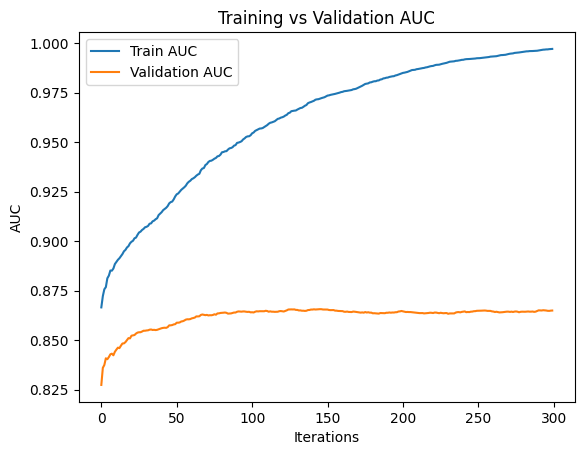

In [ ]:
# Learning curve
train_auc = evals_result['training']['auc']
val_auc = evals_result['valid_1']['auc']

plt.plot(train_auc, label="Train AUC")
plt.plot(val_auc, label="Validation AUC")
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.legend()
plt.title("Training vs Validation AUC")
plt.show()

In [6]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print("Test AUC:", roc_auc_score(y_test, y_pred_proba))

Test AUC: 0.8627298275668425


In [7]:
# basic feature importance
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(20))

                       feature  importance
14            Peptide_BLOSUM10         151
18                  Peptide_F1         133
33                Peptide_KF10         128
53             Peptide_ProtFP7         127
54             Peptide_ProtFP8         106
107  Peptide_instability_index         106
13             Peptide_BLOSUM9         105
32                 Peptide_KF9         104
8              Peptide_BLOSUM4         102
26                 Peptide_KF3          99
105   Peptide_molecular_weight          95
51             Peptide_ProtFP5          95
2                  Peptide_AF3          92
100                 Peptide_Z4          89
55                 Peptide_SV1          88
30                 Peptide_KF7          84
99                  Peptide_Z3          83
72              Peptide_SVGER6          82
16                 Peptide_PP2          82
77             Peptide_SVGER11          82


/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


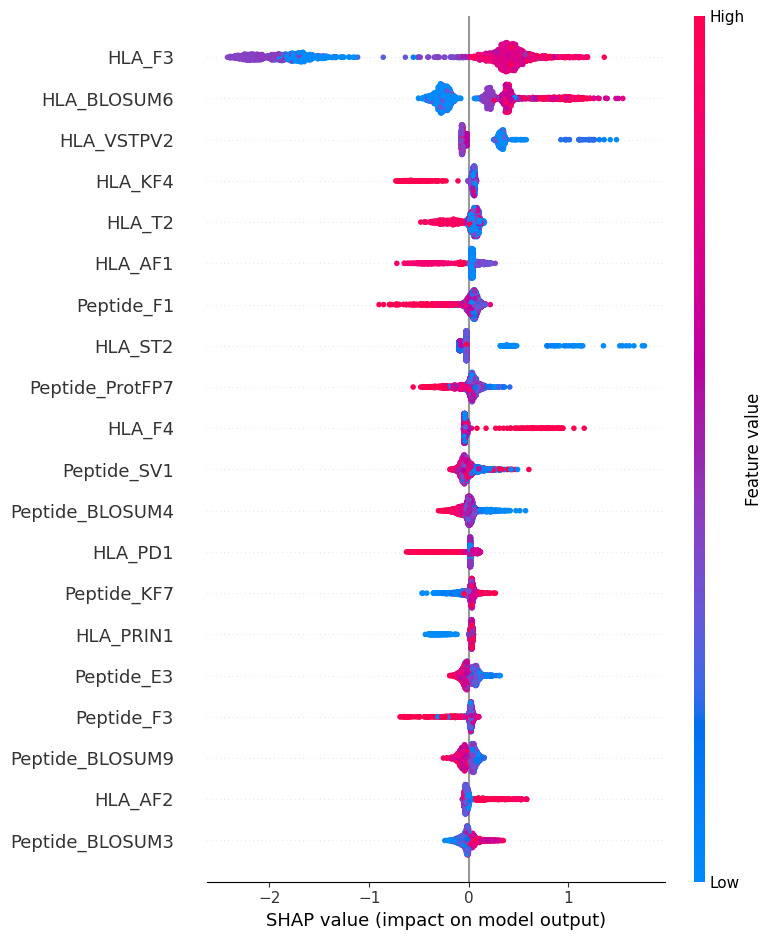

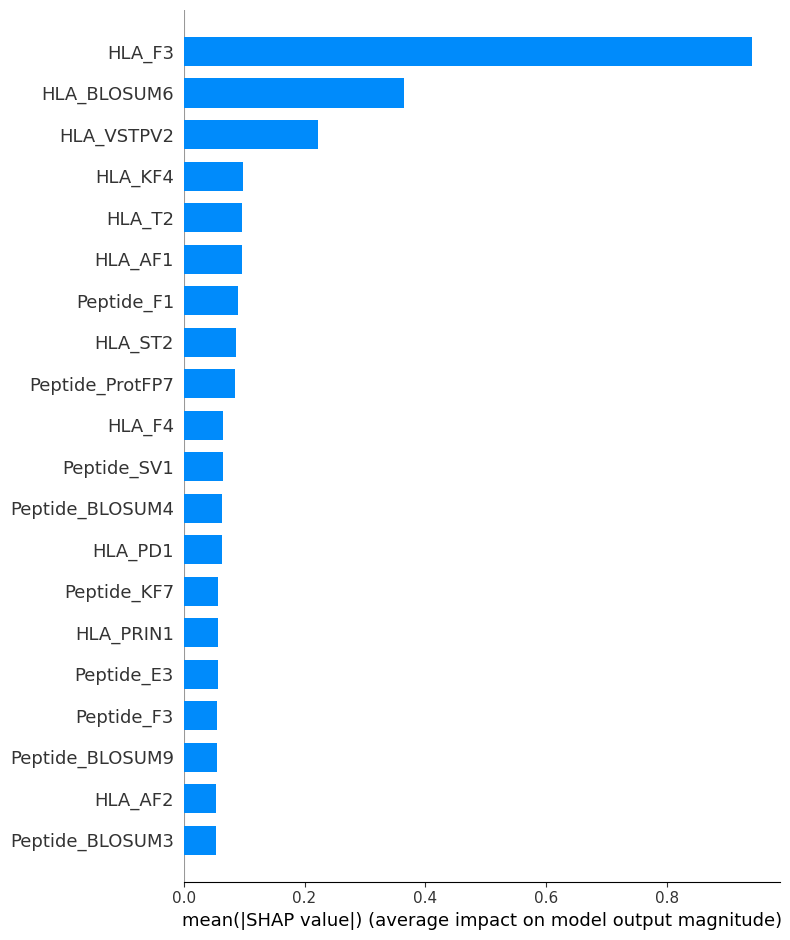

In [8]:
run_shap_analysis(model, X_test)

In [9]:
joblib.dump(
    model,
    "../models/lightgbm_datasetA_v1.pkl"
)

['../models/lightgbm_datasetA_v1.pkl']